# Attention Fundamentals: From Recurrent Bottlenecks to Query-Key-Value Attention

Sequence models such as RNN, LSTM, and GRU process information recurrently. They are effective for ordered data, but recurrent encoder-decoder models have an important limitation: a long input sequence can be compressed into a limited internal representation before the output is produced.

Attention changes this idea. Instead of forcing the model to depend on one fixed context representation, attention allows the current prediction step to directly examine the available sequence representations and assign larger weights to the most relevant positions.

The learning progression in this notebook is:

```text
limitations of recurrent models
→ attention scores
→ softmax attention weights
→ weighted context vector
→ query, key, value
→ attention visualization
```


## Why Attention Was Introduced


In a basic recurrent encoder-decoder, the encoder processes the sequence one step at a time and the decoder receives a compressed representation of the input. For long sequences, important information from early positions can be difficult to preserve.

Attention provides a direct path from the current decoder query to all encoder states.


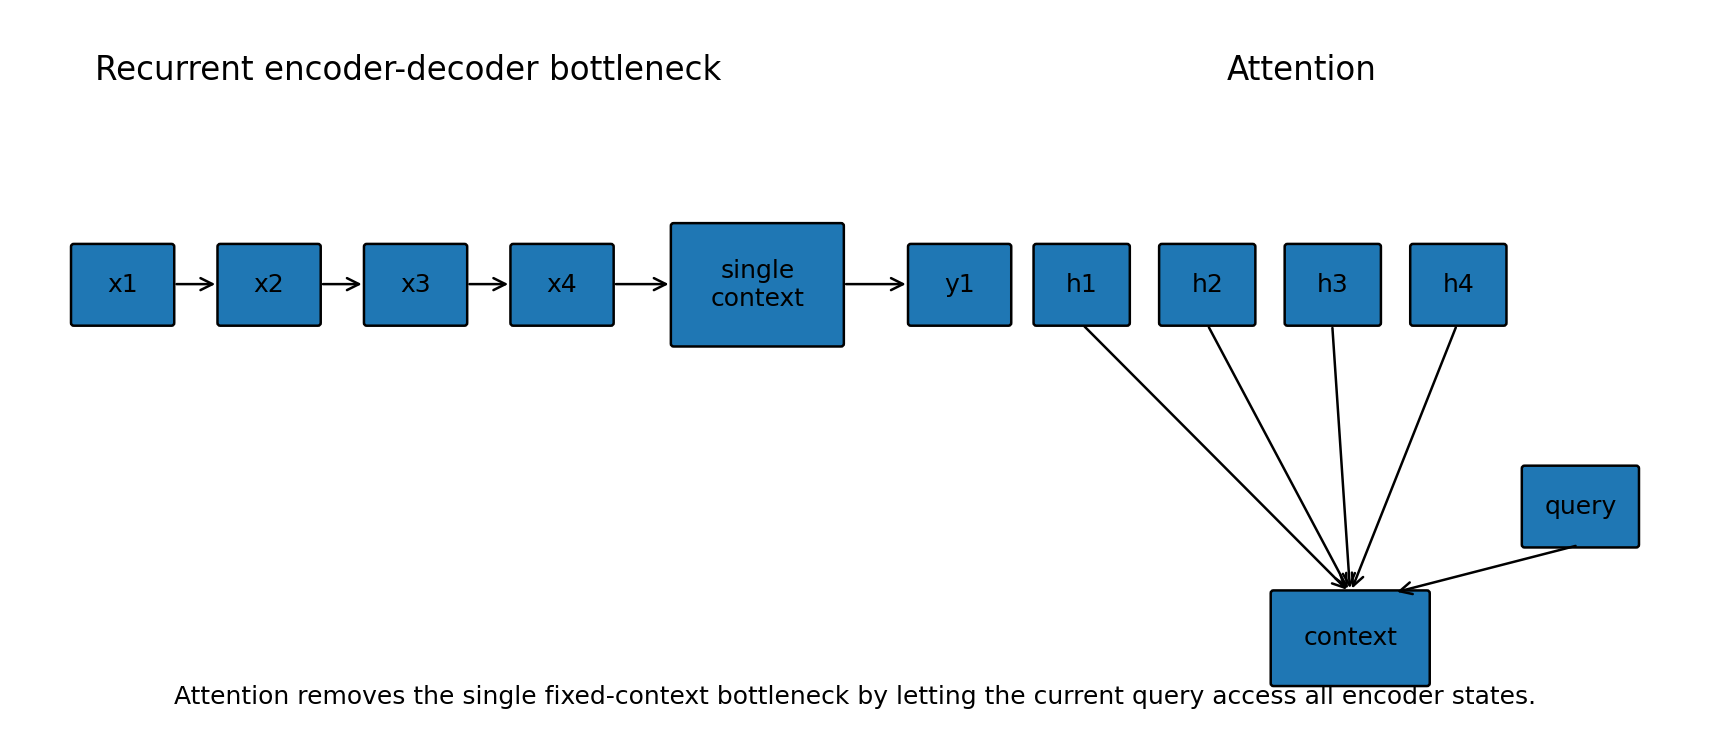

The main idea is simple:

1. compare the current query with each available sequence representation,
2. convert the comparison scores into normalized weights,
3. compute a weighted combination of the available information.


## Import Libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:',tf.__version__)


TensorFlow version: 2.20.0


## A Small Sequence of Encoder States


In [2]:
encoder_states = np.array([
    [0.2,0.7,0.1],
    [0.9,0.1,0.2],
    [0.3,0.4,0.8],
    [0.1,0.2,0.9]
],dtype=np.float32)

query = np.array([0.2,0.3,0.9],dtype=np.float32)

print('Encoder states shape:',encoder_states.shape)
print('Query shape:',query.shape)
print('\nEncoder states:')
print(encoder_states)
print('\nQuery:')
print(query)


Encoder states shape: (4, 3)
Query shape: (3,)

Encoder states:
[[0.2 0.7 0.1]
 [0.9 0.1 0.2]
 [0.3 0.4 0.8]
 [0.1 0.2 0.9]]

Query:
[0.2 0.3 0.9]


Each row of `encoder_states` represents one position in the input sequence. The query represents what the current output step is looking for.


## Step 1: Compute Attention Scores


In [3]:
scores = encoder_states @ query

print('Attention scores:')
print(scores)


Attention scores:
[0.34 0.39 0.9  0.89]


A larger score means that the corresponding encoder state is more similar to the query.

Dot-product attention uses:

$$
score(q,k_i)=q^T k_i
$$


## Step 2: Convert Scores to Attention Weights


In [4]:
def softmax(x):
    e = np.exp(x-np.max(x))
    return e/e.sum()

attention_weights = softmax(scores)

print('Attention weights:')
print(attention_weights)
print('Sum of weights:',attention_weights.sum())


Attention weights:
[0.18066205 0.1899248  0.31628007 0.31313306]
Sum of weights: 1.0


Softmax converts the raw scores into positive weights that sum to 1.

The weights can be interpreted as how much attention is assigned to each sequence position.


## Step 3: Compute the Context Vector


In [5]:
context_vector = np.sum(attention_weights[:,None]*encoder_states,axis=0)

print('Context vector:')
print(context_vector)


Context vector:
[0.33326206 0.33459455 0.590895  ]


The context vector is a weighted combination of the sequence states:

$$
context=\sum_i \alpha_i v_i
$$

where $\alpha_i$ is the attention weight and $v_i$ is the value vector at position $i$.


## Visualize the Attention Weights


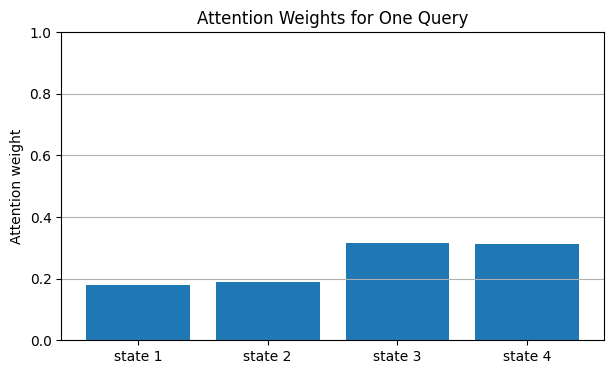

In [6]:
positions = ['state 1','state 2','state 3','state 4']

plt.figure(figsize=(7,4))
plt.bar(positions,attention_weights)
plt.title('Attention Weights for One Query')
plt.ylabel('Attention weight')
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()


## Query, Key, and Value


Attention is usually described using **Query (Q), Key (K), and Value (V)**.

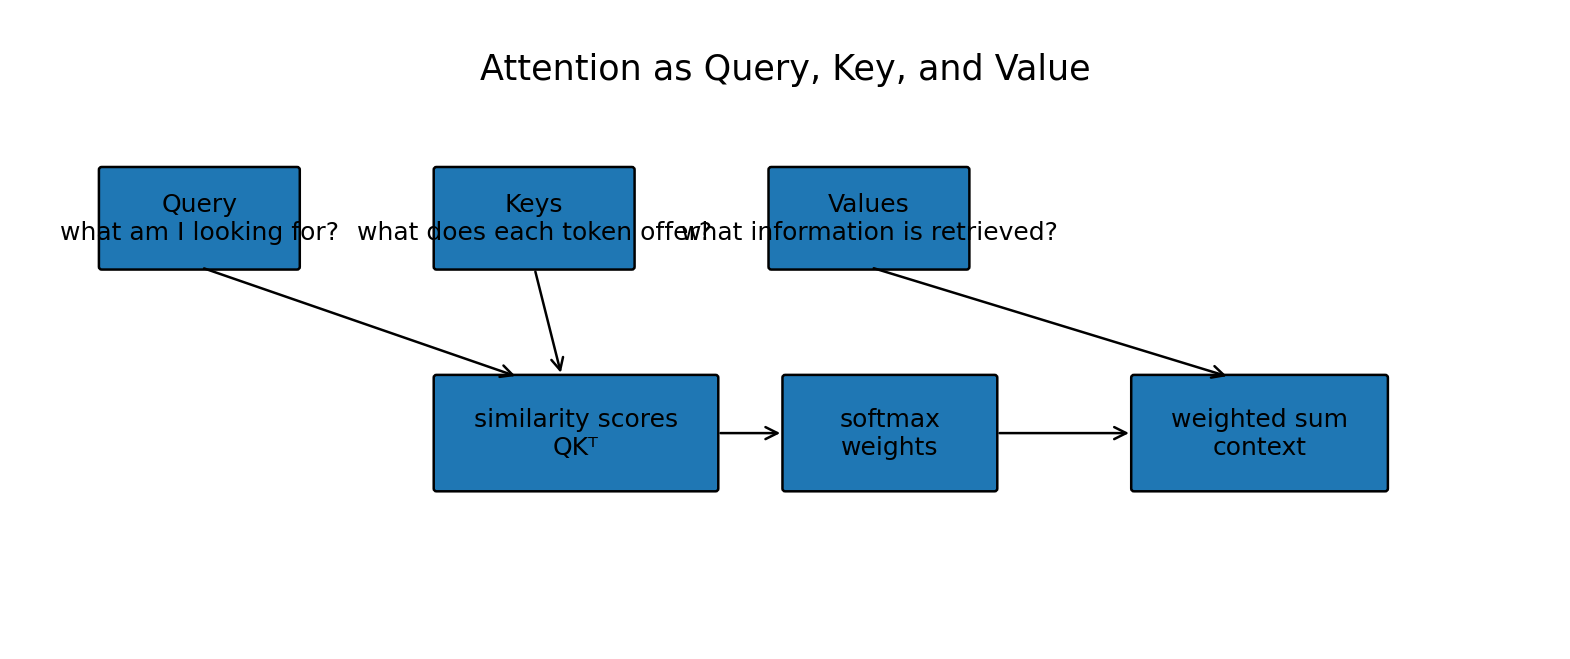

- **Query:** what the current position is looking for.
- **Key:** what each available position can be matched against.
- **Value:** the information that will be combined if that position receives attention.

The attention operation can be written as:

$$
Attention(Q,K,V)=softmax(QK^T)V
$$

The query and keys determine the weights. The values determine what information is returned.


## Query-Key-Value Attention with NumPy


In [7]:
Q = np.array([[0.2,0.3,0.9]],dtype=np.float32)
K = encoder_states.copy()
V = encoder_states.copy()

scores = Q @ K.T
weights = np.exp(scores-np.max(scores,axis=-1,keepdims=True))
weights = weights/weights.sum(axis=-1,keepdims=True)
context = weights @ V

print('Scores:')
print(scores)
print('\nWeights:')
print(weights)
print('\nContext:')
print(context)


Scores:
[[0.34 0.39 0.9  0.89]]

Weights:
[[0.18066205 0.1899248  0.31628007 0.31313306]]

Context:
[[0.3332621  0.33459455 0.590895  ]]


## Scaled Dot-Product Attention


When the key dimension becomes large, dot products can also become large. This can push softmax into very sharp regions and make optimization difficult.

Scaled dot-product attention divides the scores by the square root of the key dimension:

$$
Attention(Q,K,V)=softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$


In [8]:
dk = K.shape[-1]
scaled_scores = (Q @ K.T)/np.sqrt(dk)

weights = np.exp(scaled_scores-np.max(scaled_scores,axis=-1,keepdims=True))
weights = weights/weights.sum(axis=-1,keepdims=True)
context = weights @ V

print('Scaled scores:')
print(scaled_scores)
print('\nScaled attention weights:')
print(weights)
print('\nContext:')
print(context)


Scaled scores:
[[0.19629909 0.2251666  0.51961523 0.51384173]]

Scaled attention weights:
[[0.20899785 0.21511903 0.28877277 0.28711035]]

Context:
[[0.35074956 0.34074158 0.55334112]]


## Keras Attention Layer


In [9]:
query_tf = tf.constant(Q)
key_tf = tf.constant(K[None,:,:])
value_tf = tf.constant(V[None,:,:])

attention_layer = tf.keras.layers.Attention(use_scale=True)
context_tf,scores_tf = attention_layer([query_tf[:,None,:],value_tf,key_tf],return_attention_scores=True)

print('Keras attention scores:')
print(scores_tf.numpy())
print('\nKeras context vector:')
print(context_tf.numpy())


Keras attention scores:
[[[0.18066205 0.18992479 0.31628007 0.31313303]]]

Keras context vector:
[[[0.33326203 0.33459455 0.59089494]]]


## What Attention Learns


In a trained model, the query, key, and value representations are not fixed by hand. Their parameters are learned through backpropagation.

The model learns:

- which sequence positions should receive larger attention,
- what features make two positions relevant to one another,
- and what information should be passed through the value vectors.

This is the key step that leads from recurrent sequence models to self-attention and Transformers.


## Key Takeaways


- Recurrent encoder-decoder models can create a fixed-context bottleneck.
- Attention gives the current query direct access to all available sequence states.
- Similarity scores are converted to normalized attention weights with softmax.
- The context vector is a weighted sum of value vectors.
- Query, Key, and Value provide a general mathematical view of attention.
- Scaled dot-product attention is the form used inside Transformers.
